In [1]:
# mv this notebook in src folder
# or
# set sys path to src folder
import os, sys
path_to_scr_folder=os.path.join(os.path.dirname(os.path.abspath('')), 'src')
sys.path.append(path_to_scr_folder)


In [2]:
import plot
from read_chroma import read_only_chroma, read_chromato_and_chromato_cube
import matplotlib.pyplot as plt
from identification import compute_matches_identification, cohort_identification_alignment_input_format_txt, cohort_identification_to_csv, sample_identification
from matching import matching_nist_lib_from_chromato_cube
import projection
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

import mass_spec
from sklearn.cluster import DBSCAN
from scipy.signal import savgol_filter
from skimage.restoration import estimate_sigma
from dbscan_peak import detection_mass_par_mass_Dog

# Lecture du fichier

Loaded 103007595 mass values
Non-finite mass values: 0
[]
[]


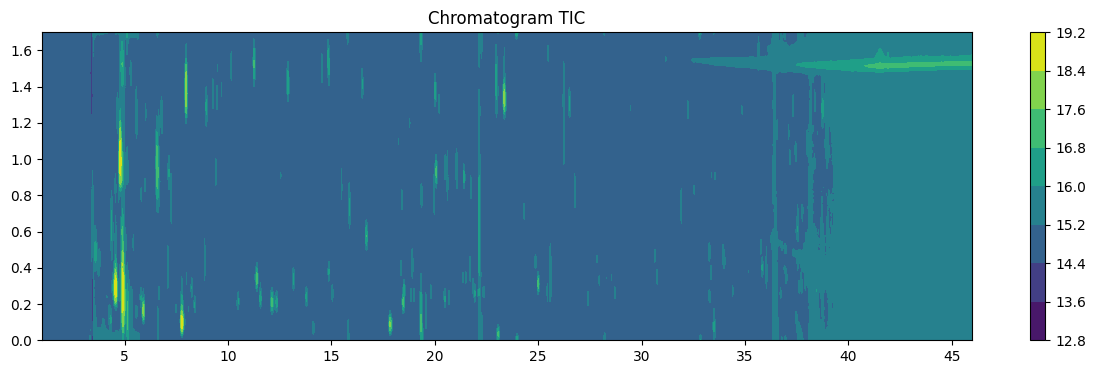

chromato read 19.20621967315674 s
--- 86.17176032066345 seconds --- to compute full spectra centroid
full spectra computed 88.88895845413208 s
baseline corrected


In [3]:
filename="/app/GCxGC/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
filename="D:/VOLATIL-CF_03/751316_QCd20new.cdf"
filename="D:/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
filename='D:/cdf centroid/B-A-009-751353-gauche-ReCIVA.cdf'
filename='D:/cdf centroid/A-F-028-817822-droite-ReCIVA.cdf'
#filename='D:/cdf centroid/B-K-031-751355-Tedlar.cdf'

chromato, time_rn, chromato_cube, sigma, mass_range=read_chromato_and_chromato_cube(filename, mod_time=1.7, pre_process=True)

In [4]:
import dbscan_peak
coordinates = dbscan_peak.detection_mass_par_mass_Dog(chromato_cube,(chromato, time_rn),
                                                            1.7,
                                                                abs_threshold=1000,
                                                                rel_threshold=0.001,
                                                                noise_factor=5,
                                                                min_sigma=1,
                                                                max_sigma=20,
                                                                sigma_ratio=2,
                                                                overlap=0.5, 
                                                                max_peak_per_mass=600,
                                                                rt1_delta=2, 
                                                                rt2_delta=0.02,
                                                                min_size_cluster_mass=2, 
                                                                thr_debscan=0.02, 
                                                                multi_processing=True,
                                                                cleaning_close_peak=True)




start peak detection
cluster_per_mass 
compute distance metric 14122 peaks
start clustering
1613 peaks clustered
1541 detected peaks after filter


c:\Users\camil\OneDrive\Documents\02-Code source\Adeline\Python-2DGC-Alignment\src\plot.py:608: RuntimeWarning: divide by zero encountered in log
  chromato = np.log(chromato)


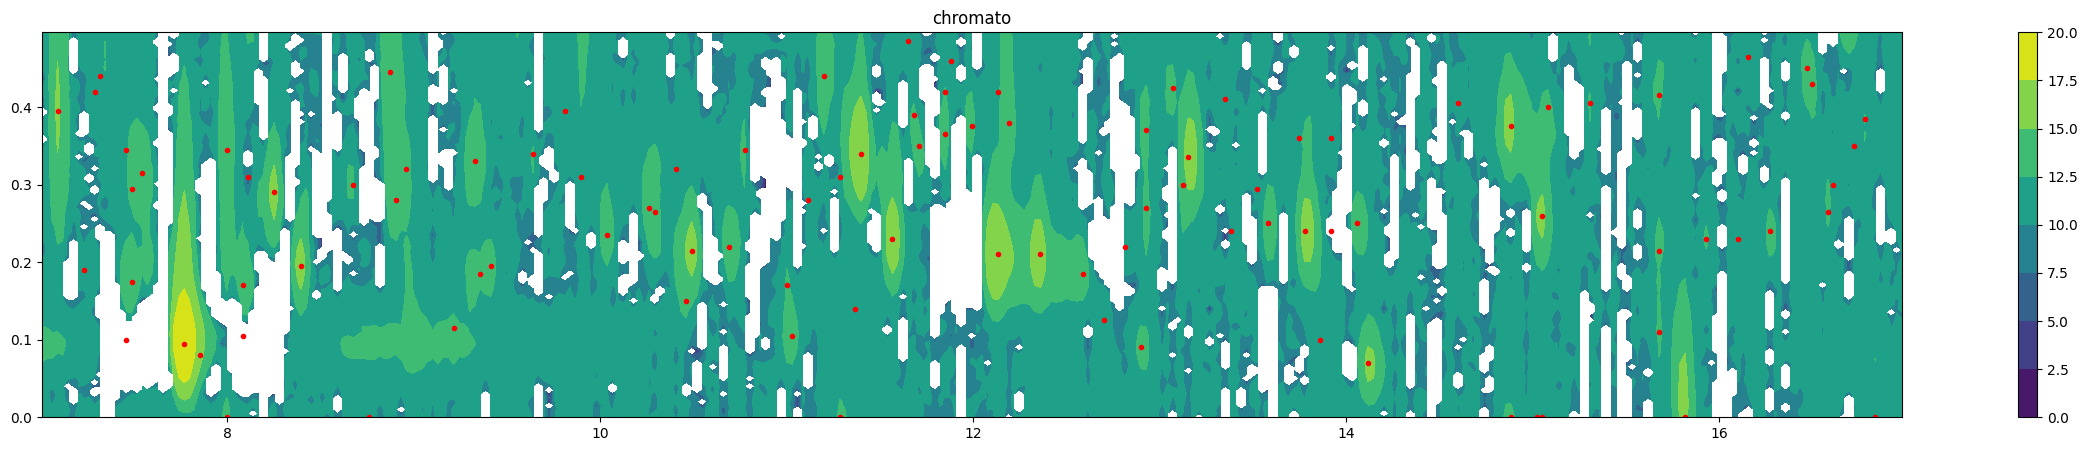

In [8]:
plt.rcParams['figure.figsize'] = [30, 5]
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato, rt1=12,rt2=0, rt2_window=0.5)

In [9]:
import matching
matches = matching.matching_nist_lib_from_chromato_cube(
            (chromato, time_rn, mass_range), chromato_cube, coordinates,
            mod_time=1.7,
            match_factor_min=650, nist=False)
base_name = os.path.basename(filename)
matches_identification, sample_metadata_list = compute_matches_identification(
            matches, chromato, chromato_cube,time_rn,1.7, mass_range,base_name,
            formated_spectra=True, quant="mass",extract_patch=True,output_hdf5_file="D:/data_set_tedlar.h5")

NIST skipped


In [13]:
base_name

'A-F-028-817822-droite-ReCIVA.cdf'

In [14]:
from identification import cohort_identification_sample_metadata
cohort_identification_sample_metadata(os.path.splitext(base_name)[0], sample_metadata_list,
                                     "D:/")

Identification started

Loaded 112300268 mass values
Non-finite mass values: 0
[]
[]


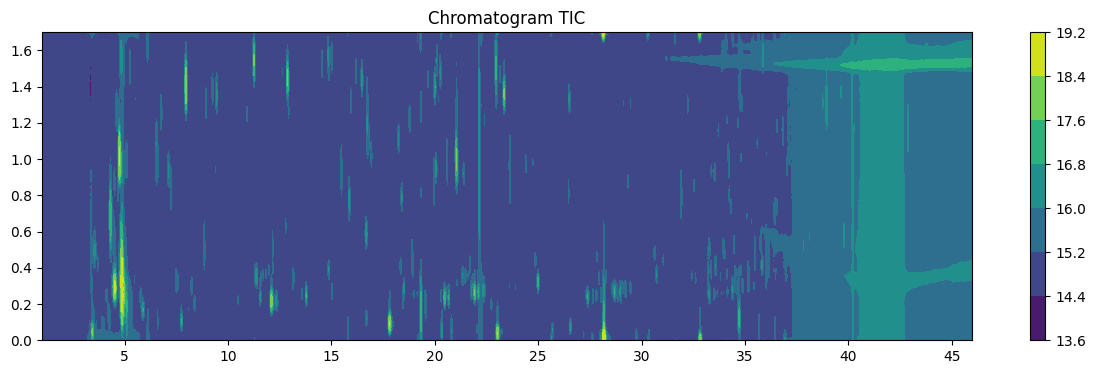

chromato read 22.419065713882446 s
--- 93.80643892288208 seconds --- to compute full spectra centroid
full spectra computed 96.53664994239807 s
baseline corrected
start peak detection
cluster_per_mass 
compute distance metric 18548 peaks
start clustering
1881 peaks clustered
1786 detected peaks after filter
nb peaks 1786


c:\Users\camil\OneDrive\Documents\02-Code source\Adeline\Python-2DGC-Alignment\src\plot.py:405: RuntimeWarning: divide by zero encountered in log
  chromato = np.log(chromato)


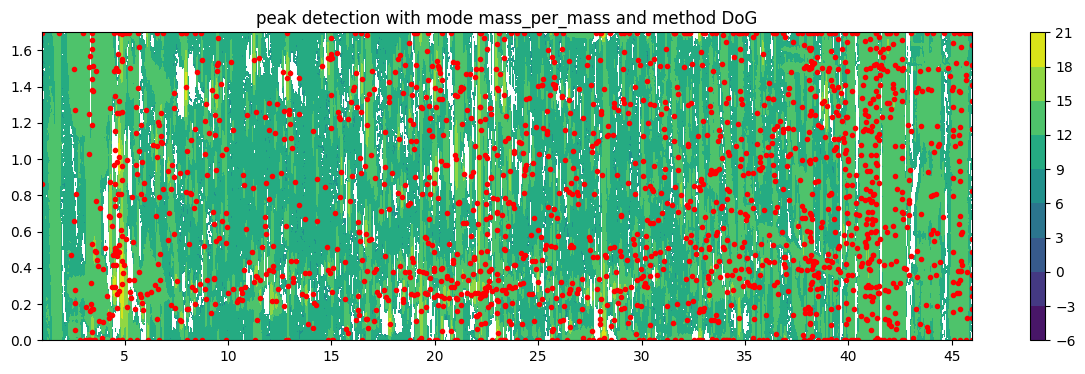

NIST skipped
nb match 1786
start integration
Identification done 310.05026626586914 s
output_path from identificqtion D:/


'D:/B-K-031-751355-Tedlar.txt created'

In [6]:
sample_identification("D:/cdf centroid", "B-K-031-751355-Tedlar.cdf", "D:/",
                          mod_time=1.7,
                          method="DoG", mode="mass_per_mass",
                          noise_factor=5, abs_thresholds=1000,
                          rel_thresholds=0.001,
                          cluster=0.5,
                          min_distance=1, min_sigma=1, max_sigma=20, sigma_ratio=2,
                          num_sigma=10,
                          formated_spectra=True, match_factor_min=600, min_persistence=0.0002,
                          overlap=0.5, eps=0.001, min_samples=1, nist=False,quant_method="mass", extract_patch=True,output_hdf5_file= "D:/data_set_tedlar.h5")

In [17]:
import h5py
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd

file_path = 'D:/data_set_tedlar.h5'
group_name = 'A-F-028-817822-droite-ReCIVA'
csv_file = 'D:/A-F-028-817822-droite-ReCIVA_sample_metadata.csv'
df = pd.read_csv(csv_file, sep=';')

with h5py.File(file_path, 'r') as h5_file:
    group = h5_file[group_name]
    keys = list(group.keys())
    clip_patch_indices = [i for i, key in enumerate(keys) if "clip_patch" in key]

    pdf = PdfPages('D:/clip_patches_A-F-028-817822-droite-ReCIVA.pdf')  # Open PDF explicitly

    for ixd in clip_patch_indices:
        selected_key = keys[ixd]
        matched_row = df[df['clip_patch_id'] == selected_key]
        data = group[selected_key][:]

        fig, ax = plt.subplots(figsize=(6, 6))
        contour_plot = ax.contourf(data.T, cmap='viridis')
        ax.set_title(f"{matched_row.iloc[0]['mass']} / { round(matched_row.iloc[0]['RT1_theoretical'],4)}/ {round(matched_row.iloc[0]['RT2_theoretical'],4)}", fontsize=10)
        ax.axis('off')

        pdf.savefig(fig)  # Save current figure to PDF
        plt.close(fig)    # Close figure to free memory

    pdf.close()  # Close the PDF file explicitly


In [7]:
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)


In [15]:
base_name

'A-F-028-817822-droite-ReCIVA.cdf'

In [ ]:
import h5py
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd

file_path = 'D:/data_set_tedlar.h5'
group_name = 'A-F-028-817822-droite-ReCIVA'
csv_file = 'D:/A-F-028-817822-droite-ReCIVA_sample_metadata.csv'
df = pd.read_csv(csv_file, sep=';')

with h5py.File(file_path, 'r') as h5_file:
    group = h5_file[group_name]
    keys = list(group.keys())
    clip_patch_indices = [i for i, key in enumerate(keys) if "clip_patch" in key]

    pdf = PdfPages('D:/clip_patches_plots_A-F-028-817822-droite-ReCIVA.pdf')  # Open PDF explicitly

    for ixd in clip_patch_indices[:1500]:
        selected_key = keys[ixd]
        matched_row = df[df['clip_patch_id'] == selected_key]
        data = group[selected_key][:]
        
        plt.rcParams['figure.figsize'] = [10, 5]
        fig=plot.visualizer2((chromato_cube[matched_row.iloc[0]['mass']-mass_range[0],:,:], time_rn), 
                         title=f"{matched_row.iloc[0]['mass']} / { round(matched_row.iloc[0]['RT1_theoretical'],4)}/ {round(matched_row.iloc[0]['RT2_theoretical'],4)}", 
                         log_chromato=False,  mod_time=1.7, 
                 rt1=matched_row.iloc[0]['RT1_theoretical'], rt2=matched_row.iloc[0]['RT2_theoretical'], 
                 rt1_window=0.1,rt2_window=0.2,points=coordinates_in_chromato)

        pdf.savefig(fig)  # Save current figure to PDF
        plt.close(fig)    # Close figure to free memory

    pdf.close()  # Close the PDF file explicitly

In [7]:
import pandas as pd
import glob
import os

# Folder where your files are located
folder_path = "D:/"

# Find all CSV files ending with 'metadata.csv'
csv_files = glob.glob(os.path.join(folder_path, "*metadata.csv"))

# List to collect all DataFrames
df_list = []

for file in csv_files:
    print(f"Reading: {file}")
    df = pd.read_csv(file, sep=';')  # Adjust sep if needed
    df_list.append(df)

# Concatenate all DataFrames
df_combined = pd.concat(df_list, ignore_index=True)

# Save to a new CSV if needed
df_combined.to_csv(os.path.join(folder_path, "combined_metadata.csv"), sep=';', index=False)

Reading: D:/H-N-027-802116-Tedlarsample_metadata.csv
Reading: D:/M-J-022-864685-Tedlarsample_metadata.csv
Reading: D:/T-T-030-801850-Tedlarsample_metadata.csv


In [5]:
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)

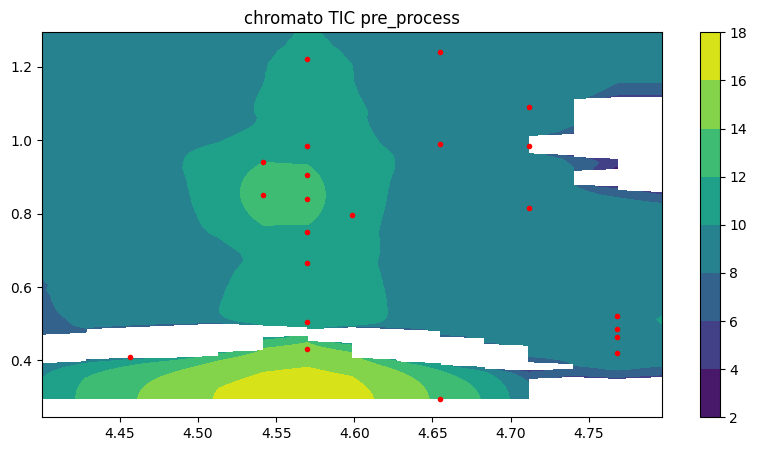

In [24]:
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plt.rcParams['figure.figsize'] = [10, 5]
plot.visualizer2((chromato_cube[68-mass_range[0],:,:], time_rn), title="chromato TIC pre_process", log_chromato=True,  mod_time=1.7, 
                 rt1=4.5983, rt2=0.795, 
                 rt1_window=0.2,rt2_window=0.5,points=coordinates_in_chromato)

# Wrapper

start peak detection
cluster_per_mass 
compute distance metric 16429 peaks
start clustering
1708 peaks clustered
1635 detected peaks after filter


c:\Users\camil\OneDrive\Documents\02-Code source\Adeline\Python-2DGC-Alignment\src\plot.py:632: RuntimeWarning: divide by zero encountered in log
  chromato = np.log(chromato)


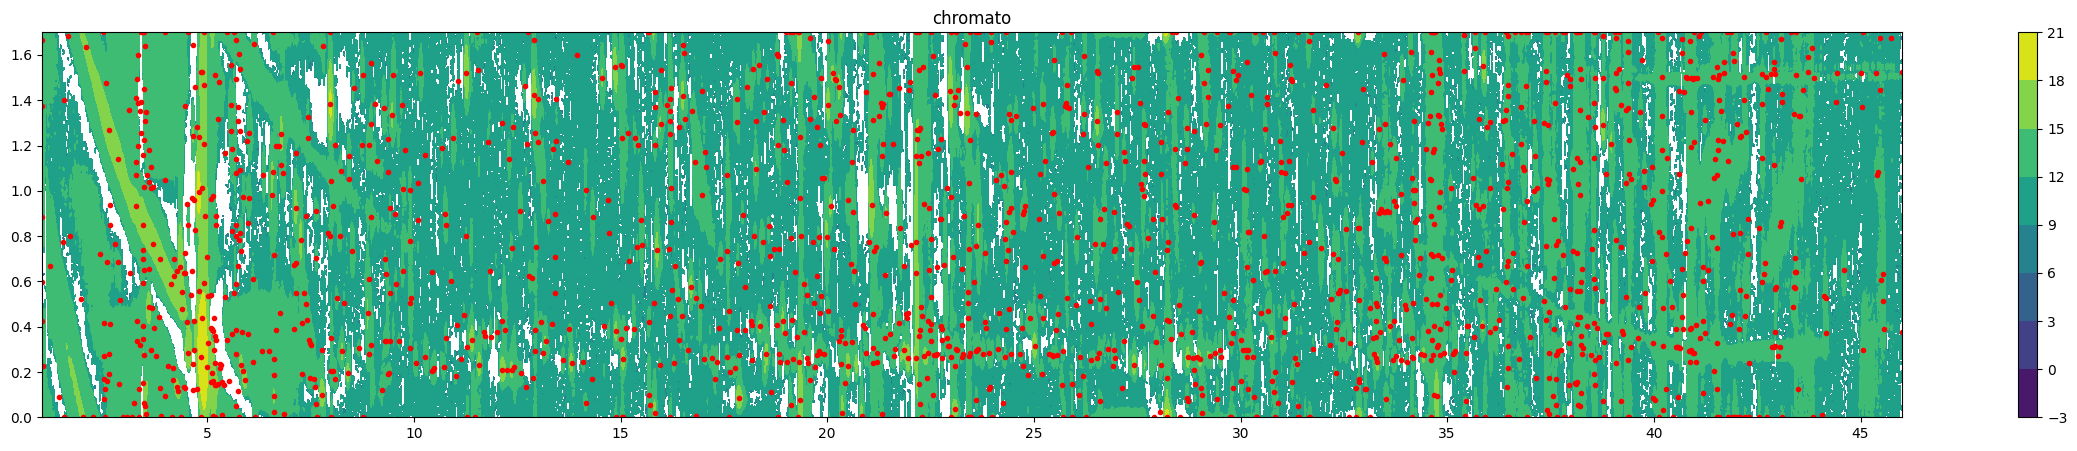

In [10]:
mod_time=1.7
coordinate = detection_mass_par_mass_Dog(chromato_cube,(chromato, time_rn),mod_time=mod_time,abs_threshold=1000,noise_factor=5, rel_threshold= 0.001)
plt.rcParams['figure.figsize'] = [30, 5]
coordinates_in_chromato=projection.matrix_to_chromato(coordinate, time_rn, mod_time, chromato.shape)
plot.visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=mod_time,points=coordinates_in_chromato)

c:\Users\camil\OneDrive\Documents\02-Code source\Adeline\Python-2DGC-Alignment\src\plot.py:632: RuntimeWarning: divide by zero encountered in log
  chromato = np.log(chromato)


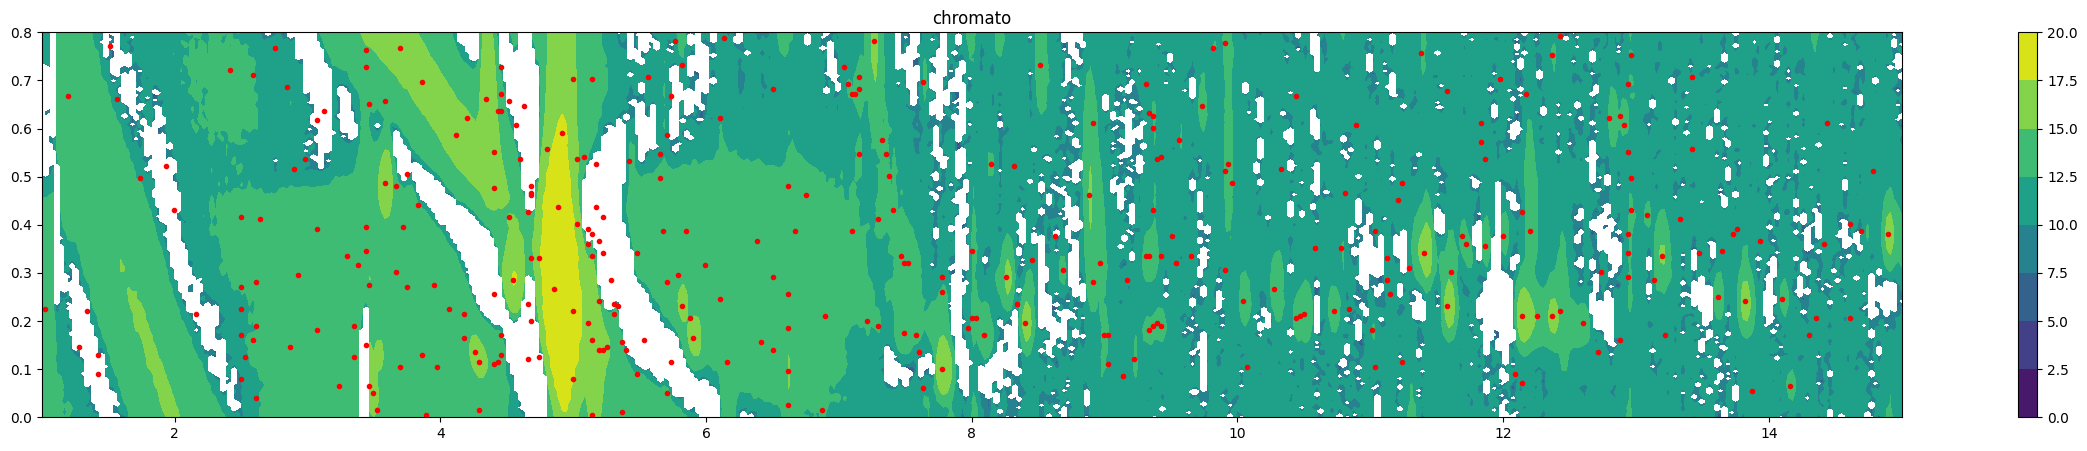

In [9]:
plot.visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato,rt2=0.3, rt1=5, rt2_window=0.5,rt1_window=10)

In [6]:
from dbscan_peak import detect_peak_dog_mp,cluster_per_mass,rt_penalty

results= detect_peak_dog_mp(chromato_cube,
                            abs_threshold=600,
                       rel_threshold=0.0001,
                       noise_factor=5,
                       min_sigma=1, max_sigma=20,
                       sigma_ratio=2,
                       overlap=0.5,multi_processing=True)
print("start cluster")    
results=cluster_per_mass(results,chromato_cube,time_rn,1.7,rt1_delta=5, rt2_delta=0.1,thr_debscan=0.05,max_peak_per_mass=600)
results = [res for res in results if res is not None]
coordinates_all_mass=[]
for elt in results:
    for x,y,z in elt:
        coordinates_all_mass.append([x,y,z])
    

start cluster


In [7]:
coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1)
rt_values= projection.matrix_to_chromato(coordinates_all_mass, time_rn, 1.7, chromato_cube[0,:,:].shape)

In [8]:
intensity_values_list = []
for i, coordinate in enumerate(coordinates_all_mass):
    int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
    intensity_values_list.append(np.concatenate(([rt_values[i,0]*60,rt_values[i,1]], int_values)))
intensity_values_list = np.array(intensity_values_list)


In [9]:
rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
spectra = intensity_values_list[:, 2:]  # shape (n, m)

In [10]:
from scipy.spatial.distance import cdist
import numpy as np

def rt_penalty_fast(rt_vals, rt1_delta=5, rt2_delta=0.1):
    # Normalize RTs by their respective deltas (acts like weighting)
    scaled_rt = rt_vals / np.array([rt1_delta, rt2_delta])
    
    # Compute Manhattan (L1) distance between all rows
    penalty_matrix = cdist(scaled_rt, scaled_rt, metric='cityblock')  # sum of |ΔRT1| + |ΔRT2|
    return penalty_matrix

In [11]:
rt_penalty_value= rt_penalty_fast(rt_vals,2,0.02)

In [12]:
from sklearn.metrics.pairwise import cosine_distances
batch_size=10000
import gc
# Assume `spectra` is already a (60000, m) numpy array
n_samples = spectra.shape[0]
    # Optional: use float32 to reduce memory (only if precision is acceptable)
spectra = spectra.astype(np.float32)

    # Preallocate output matrix
spec_dists = np.zeros((n_samples, n_samples), dtype=np.float32)

for start in range(0, n_samples, batch_size):
    print(start)
    end = min(start + batch_size, n_samples)

        # Compute distances from batch to all
    dist_batch = cosine_distances(spectra[start:end], spectra)
    spec_dists[start:end, :] = dist_batch

    del dist_batch
    gc.collect()




0
10000
20000
30000


In [15]:
spec_dists = spec_dists.astype(np.float32)
rt_penalty_value = rt_penalty_value.astype(np.float32)

In [16]:
distance_matrix = spec_dists + 0.01 *rt_penalty_value

In [13]:
# Only compute combined distance where rt_penalty_value < 1
mask = rt_penalty_value < 10

# Allocate result with NaNs or sparse format
final_dist = np.full_like(spec_dists, 1)
final_dist[mask] = spec_dists[mask] + 0.01 * rt_penalty_value[mask]

In [18]:
from dbscan_peak import cluster_peak
coordinates, clusters= cluster_peak(distance_matrix,chromato,coordinates_all_mass,thr_debscan=0.02,min_sample_db_scan=2)
len(coordinates)

4130

# Detecton masse par masse

In [158]:
coordinates

array([[ 789.,  268.],
       [ 393.,   42.],
       [ 495.,  246.],
       ...,
       [1573.,   59.],
       [ 168.,  110.],
       [1546.,  291.]])

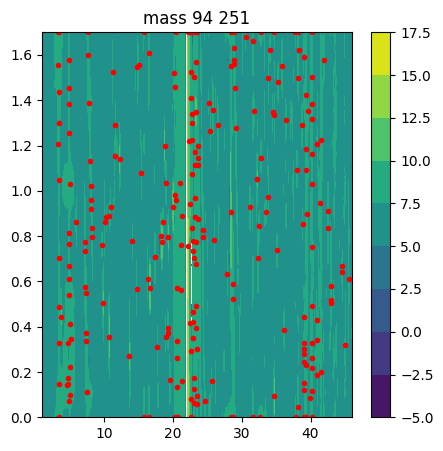

In [161]:

from peak_detection import intensity_threshold_decision_rule, pers_hom, DoG

mass=49+mass_range[0]
#mass=49+mass_range[0]
mass=94
tmp= chromato_cube[mass-mass_range[0],:,:]

sigma = estimate_sigma(tmp, channel_axis=None)
MIN_SEUIL = min(2 * sigma * 100 / np.max(tmp),0.01)
# detect peaks

intensity_threshold = intensity_threshold_decision_rule(
            abs_threshold=1000, rel_threshold=0.0000001, noise_factor=5, sigma=sigma, chromatogram=tmp)
MIN_SEUIL= intensity_threshold / np.max(tmp)
# coordinates = skimage.feature.peak_local_max(
#             tmp,
#             min_distance=1,
#             threshold_abs=intensity_threshold)

# coordinates = pers_hom(chromato_obj=(
#                 tmp, time_rn),
#                 abs_threshold=1500,
#                 rel_threshold=0.00001,
#                 noise_factor=3,
#                 sigma=sigma,
#                 min_persistence=0.0002, mode="tic",
#                 chromato_cube=chromato_cube, cluster=0.5,
#                 eps=0.01,
#                 min_samples=1)
coordinates, radius = DoG(chromato_obj=(
                    tmp, time_rn),
                    abs_threshold=500,
                    rel_threshold=0.00001,
                    noise_factor=3,
                    sigma=sigma,
                    min_sigma=1, max_sigma=20,
                    sigma_ratio=2, mode="tic",
                    chromato_cube=chromato_cube, 
                    cluster=0.5,
                    overlap=0.5,
                    eps=0.1,
                    min_samples=1)
npeak= len(coordinates)
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
coordinates=coordinates.astype('int')
# intensity_values_list = []
# for i, coordinate in enumerate(coordinates):
#     int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
#     rt_values= projection.matrix_to_chromato(coordinates[[i]], time_rn, 1.7, chromato.shape)
#     intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

# intensity_values_list = np.array(intensity_values_list)

# # Separate RT and spectrum
# rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
# spectra = intensity_values_list[:, 2:]  # shape (n, m)

# # Compute cosine distances in vectorized form
# spec_dists = cosine_distances(spectra)

# # Compute RT penalty (broadcasted)
# rt1 = rt_vals[:, 0][:, None]
# rt2 = rt_vals[:, 0][None, :]
# rt1_penalty = np.abs(rt1 - rt2) / 5

# rt3 = rt_vals[:, 1][:, None]
# rt4 = rt_vals[:, 1][None, :]
# rt2_penalty = np.abs(rt3 - rt4) * 10

# total_penalty = 0.01 * (rt1_penalty + rt2_penalty)
# distance_matrix = spec_dists + total_penalty

# # Apply DBSCAN with precomputed distance matrix
# clustering = DBSCAN(eps=0.05, min_samples=1, metric='precomputed').fit(distance_matrix)

# clusters = []
# for i in range((np.max(clustering.labels_) + 1)):
#     clusters.append([])
# for i, (t1, t2) in enumerate(coordinates):
#     clusters[clustering.labels_[i]].append([t1, t2])
# coordinates = []
# for cluster in clusters:
#     if (len(cluster) > 1):
#         coord = cluster[np.argmax(np.array([tmp[coord[0], coord[1]] for coord in cluster]))]
#     else:
#         coord = cluster[0]
#     coordinates.append(coord)
# coordinates = np.array(coordinates)
# ncluster=len(clusters)

# if ncluster>600:
#     intensities = np.array([tmp[coord[0], coord[1]] for coord in coordinates])
#     top_indices = np.argsort(intensities)[-1000:][::-1]  # descending order
#     coordinates = coordinates[top_indices]
#     npeak= len(coordinates)

coordinates_in_chromato_new=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer2(((tmp), time_rn), title="mass " + str(mass) + " " +str(npeak), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)
#visualizer2(((tmp), time_rn), title= str(npeak-ncluster) + " clustered peaks " + str(round(MIN_SEUIL,3)) + " " +str(ncluster), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato_new)


In [162]:
coordinates_in_chromato_new

array([[2.21530971e+01, 7.57227139e-01],
       [2.21530971e+01, 1.70000000e+00],
       [2.00831560e+01, 9.27728614e-01],
       [1.67088684e+01, 5.71681416e-01],
       [1.84385452e+01, 7.72271386e-01],
       [1.07825986e+01, 3.56047198e-01],
       [2.24650061e+01, 9.42772861e-01],
       [2.84196312e+01, 9.07669617e-01],
       [3.47428761e+01, 9.52802360e-02],
       [1.88071649e+01, 1.19852507e+00],
       [2.33723775e+01, 1.34896755e+00],
       [1.23137879e+01, 1.13834808e+00],
       [1.93742720e+01, 7.97345133e-01],
       [9.90358247e+00, 5.06489676e-01],
       [3.22759599e+01, 1.05309735e+00],
       [1.37032004e+01, 2.70796460e-01],
       [3.83553586e+00, 4.41297935e-01],
       [3.16521421e+01, 1.65988201e+00],
       [2.03667096e+01, 0.00000000e+00],
       [1.48657701e+01, 1.54454277e+00],
       [3.58770904e+01, 1.54955752e+00],
       [1.12646397e+01, 1.52448378e+00],
       [1.01020700e+01, 8.62536873e-01],
       [3.81738744e+01, 4.51327434e-02],
       [2.028164

In [ ]:
from dbscan_peak import process_mass

results=[]
for mass in range(chromato_cube.shape[0]):
    results.append(process_mass(mass,chromato_cube,time_rn))

c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\camil\AppData\Loca

In [21]:
results=list

In [22]:
results = [x for x in results if x is not None]
list=[]
for elt in results:
    for x,y,z in elt:
        list.append([x,y,z])
len(list)

25720

In [ ]:
np.argmax([len(x) for x in results])

310

In [ ]:
plt.rcParams['figure.figsize'] = [20, 5]

pdf = matplotlib.backends.backend_pdf.PdfPages("C:/Users/camil/OneDrive/Documents/05-stages/2025- CDD GCgC/DBscan/plot_mass_detection_log_dog.pdf")
for mass in range(chromato_cube.shape[0]):
    chromato_m= chromato_cube[mass,:,:]
    tmp = np.empty_like(chromato)
    for i in range(tmp.shape[1]):
            tmp[:, i] = chromato_m[:, i] - pybaselines.whittaker.asls(chromato_m[:, i],
                                                        #lam=10**7,
                                                        lam=10**3, 
                                                        p=0.01,
                                                        #p=10**-3
                                                        )[0]
            tmp[tmp < .0] = 0
    tmp= savgol_filter(tmp,  50, 3, mode='nearest')
    tmp[tmp<0]=0

    sigma = estimate_sigma(tmp, channel_axis=None)
    MIN_SEUIL = min(2 * sigma * 100 / np.max(tmp),0.01)
    # detect peaks

    intensity_threshold = intensity_threshold_decision_rule(
                abs_threshold=1000, rel_threshold=0.0000001, noise_factor=5, sigma=sigma, chromatogram=tmp)
    MIN_SEUIL= intensity_threshold / np.max(tmp)
    # coordinates = skimage.feature.peak_local_max(
    #             tmp,
    #             min_distance=1,
    #             threshold_abs=intensity_threshold)

    # coordinates = pers_hom(chromato_obj=(
    #                 tmp, time_rn),
    #                 abs_threshold=1500,
    #                 rel_threshold=0.00001,
    #                 noise_factor=3,
    #                 sigma=sigma,
    #                 min_persistence=0.0002, mode="tic",
    #                 chromato_cube=chromato_cube, cluster=0.5,
    #                 eps=0.01,
    #                 min_samples=1)
    coordinates, radius = DoG(chromato_obj=(
                        tmp, time_rn),
                        abs_threshold=500,
                        rel_threshold=0.00001,
                        noise_factor=3,
                        sigma=sigma,
                        min_sigma=1, max_sigma=20,
                        sigma_ratio=2, mode="tic",
                        chromato_cube=chromato_cube, 
                        cluster=0.5,
                        overlap=0.5,
                        eps=0.1,
                        min_samples=1)
    npeak= len(coordinates)
    coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)

    intensity_values_list = []
    for i, coordinate in enumerate(coordinates):
        int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
        rt_values= projection.matrix_to_chromato(coordinates[[i]], time_rn, 1.7, chromato.shape)
        intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

    intensity_values_list = np.array(intensity_values_list)

    # Separate RT and spectrum
    rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
    spectra = intensity_values_list[:, 2:]  # shape (n, m)

    # Compute cosine distances in vectorized form
    spec_dists = cosine_distances(spectra)

    # Compute RT penalty (broadcasted)
    rt1 = rt_vals[:, 0][:, None]
    rt2 = rt_vals[:, 0][None, :]
    rt1_penalty = np.abs(rt1 - rt2) / 5

    rt3 = rt_vals[:, 1][:, None]
    rt4 = rt_vals[:, 1][None, :]
    rt2_penalty = np.abs(rt3 - rt4) * 10

    total_penalty = 0.01 * (rt1_penalty + rt2_penalty)
    distance_matrix = spec_dists + total_penalty

    # Apply DBSCAN with precomputed distance matrix
    clustering = DBSCAN(eps=0.05, min_samples=1, metric='precomputed').fit(distance_matrix)

    clusters = []
    for i in range((np.max(clustering.labels_) + 1)):
        clusters.append([])
    for i, (t1, t2) in enumerate(coordinates):
        clusters[clustering.labels_[i]].append([t1, t2])
    coordinates = []
    for cluster in clusters:
        if (len(cluster) > 1):
            coord = cluster[np.argmax(np.array([tmp[coord[0], coord[1]] for coord in cluster]))]
        else:
            coord = cluster[0]
        coordinates.append(coord)
    coordinates = np.array(coordinates)
    ncluster=len(clusters)

    if ncluster>600:
        intensities = np.array([tmp[coord[0], coord[1]] for coord in coordinates])
        top_indices = np.argsort(intensities)[-1000:][::-1]  # descending order
        coordinates = coordinates[top_indices]
        npeak= len(coordinates)

    coordinates_in_chromato_new=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
    fig1=visualizer2(((tmp), time_rn), title="mass " + str(mass + mass_range[0]) + " " +str(npeak), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)
    fig2=visualizer2(((tmp), time_rn), title= str(npeak-ncluster) + " clustered peaks " + str(round(MIN_SEUIL,3)) + " " +str(ncluster), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato_new)
    pdf.savefig(fig1)
    plt.close(fig1) 
    pdf.savefig(fig2)
    plt.close(fig2)
    print(mass)
pdf.close()

In [73]:
mass

224

In [74]:
pdf.close()

# Clusturing across mass

In [19]:
coordinates_all_mass=list
coordinates_all_mass


[[[0, 137, 120],
  [0, 297, 186],
  [0, 221, 157],
  [0, 281, 257],
  [0, 137, 293],
  [0, 220, 132],
  [0, 137, 146],
  [0, 281, 239],
  [0, 297, 202],
  [0, 125, 67]],
 [[1, 134, 202],
  [1, 246, 278],
  [1, 138, 44],
  [1, 129, 249],
  [1, 126, 85],
  [1, 131, 58],
  [1, 162, 249],
  [1, 216, 79],
  [1, 137, 304],
  [1, 647, 7],
  [1, 220, 147],
  [1, 720, 187],
  [1, 239, 21]],
 [[2, 134, 203],
  [2, 126, 57],
  [2, 246, 276],
  [2, 138, 56],
  [2, 215, 78],
  [2, 647, 22],
  [2, 129, 253],
  [2, 362, 303],
  [2, 746, 120],
  [2, 647, 339],
  [2, 281, 257],
  [2, 173, 32],
  [2, 129, 267],
  [2, 177, 250],
  [2, 138, 142],
  [2, 126, 102],
  [2, 78, 27],
  [2, 220, 145],
  [2, 73, 339],
  [2, 138, 310],
  [2, 198, 13],
  [2, 125, 170],
  [2, 74, 0],
  [2, 647, 59],
  [2, 115, 29],
  [2, 215, 110],
  [2, 138, 335],
  [2, 776, 287],
  [2, 134, 254],
  [2, 88, 11],
  [2, 647, 314],
  [2, 692, 195],
  [2, 891, 255],
  [2, 745, 281],
  [2, 489, 310],
  [2, 161, 250],
  [2, 217, 185],
  

In [20]:
coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1)
intensity_values_list = []
for i, coordinate in enumerate(coordinates_all_mass):
    int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
    rt_values= projection.matrix_to_chromato(coordinates_all_mass[[i]], time_rn, 1.7, chromato.shape)
    intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

intensity_values_list = np.array(intensity_values_list)
#from dbscan_peak import rt_penalty, cluster_peak
rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
spectra = intensity_values_list[:, 2:]  # shape (n, m)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (352,) + inhomogeneous part.

In [130]:
# Compute cosine distances in vectorized form
spec_dists = cosine_distances(spectra)

In [15]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
import gc
# Assume `spectra` is already a (60000, m) numpy array
n_samples = spectra.shape[0]
batch_size = 20000  # can adjust based on your RAM

# Optional: use float32 to reduce memory (only if precision is acceptable)
spectra = spectra.astype(np.float32)

# Preallocate output matrix
spec_dists = np.zeros((n_samples, n_samples), dtype=np.float32)

for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    print(f"Processing rows {start} to {end}...")

    # Compute distances from batch to all
    dist_batch = cosine_distances(spectra[start:end], spectra)
    spec_dists[start:end, :] = dist_batch

    del dist_batch
    gc.collect()

print("Full cosine distance matrix computed with shape:", spec_dists.shape)

Processing rows 0 to 20000...
Processing rows 20000 to 34803...
Full cosine distance matrix computed with shape: (34803, 34803)


In [131]:
rt_penalty_value= rt_penalty(rt_vals,rt1_delta=2, rt2_delta=0.02)
distance_matrix = spec_dists + 0.01 *rt_penalty_value
clustering = DBSCAN(eps=0.02, min_samples=2, metric='precomputed').fit(distance_matrix)

In [132]:
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
intra_distances =[]
for label in unique_labels:
    cluster_points = coordinates_all_mass[labels == label]
    if len(cluster_points) > 1:
            centroid = np.mean(cluster_points, axis=0)
            dists = np.linalg.norm(cluster_points - centroid, axis=1)
            intra_distances.append(np.mean(dists))

overall_mean = np.mean(intra_distances) if intra_distances else np.nan
overall_mean

1.7397744566642552

In [133]:
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
ncluster=len(unique_labels)

clusters = []
for i in range(ncluster):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates_all_mass):
    if(clustering.labels_[i]!= -1):
        clusters[clustering.labels_[i]].append([t1, t2])
coordinates = []
for cluster in clusters:
    if (len(cluster) > 1):
        coord = cluster[np.argmax(np.array([chromato[coord[0], coord[1]] for coord in cluster]))]
    else:
        coord = cluster[0]
    coordinates.append(coord)
coordinates = np.array(coordinates)
len(coordinates)

2132

In [10]:
coordinates= detection_mass_par_mass(chromato_cube,chromato, time_rn, mass_range)

c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [116]:
len(coordinates)

5134

In [134]:
intensity_values_list = []
for i, coordinate in enumerate(coordinates):
    int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
    rt_values= projection.matrix_to_chromato(coordinates[[i]], time_rn, 1.7, chromato.shape)
    intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

intensity_values_list = np.array(intensity_values_list)

# Separate RT and spectrum
rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
spectra = intensity_values_list[:, 2:]  # shape (n, m)

# Compute cosine distances in vectorized form
spec_dists = cosine_distances(spectra)

# Compute RT penalty (broadcasted)
rt1 = rt_vals[:, 0][:, None]
rt2 = rt_vals[:, 0][None, :]
rt1_penalty = np.abs(rt1 - rt2) / 2*1.7

rt3 = rt_vals[:, 1][:, None]
rt4 = rt_vals[:, 1][None, :]
rt2_penalty = np.abs(rt3 - rt4) / 0.1

total_penalty = 0.01 * (rt1_penalty + rt2_penalty)
distance_matrix = spec_dists + total_penalty

# Apply DBSCAN with precomputed distance matrix
clustering = DBSCAN(eps=0.03, min_samples=1, metric='precomputed').fit(distance_matrix)

In [135]:
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
ncluster=len(unique_labels)

clusters = []
for i in range(ncluster):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates):
    if(clustering.labels_[i]!= -1):
        clusters[clustering.labels_[i]].append([t1, t2])
coordinates_final = []
for cluster in clusters:
    if (len(cluster) > 1):
        coord = cluster[np.argmax(np.array([chromato[coord[0], coord[1]] for coord in cluster]))]
    else:
        coord = cluster[0]
    coordinates_final.append(coord)
coordinates_final = np.array(coordinates_final)
len(coordinates_final)

1806

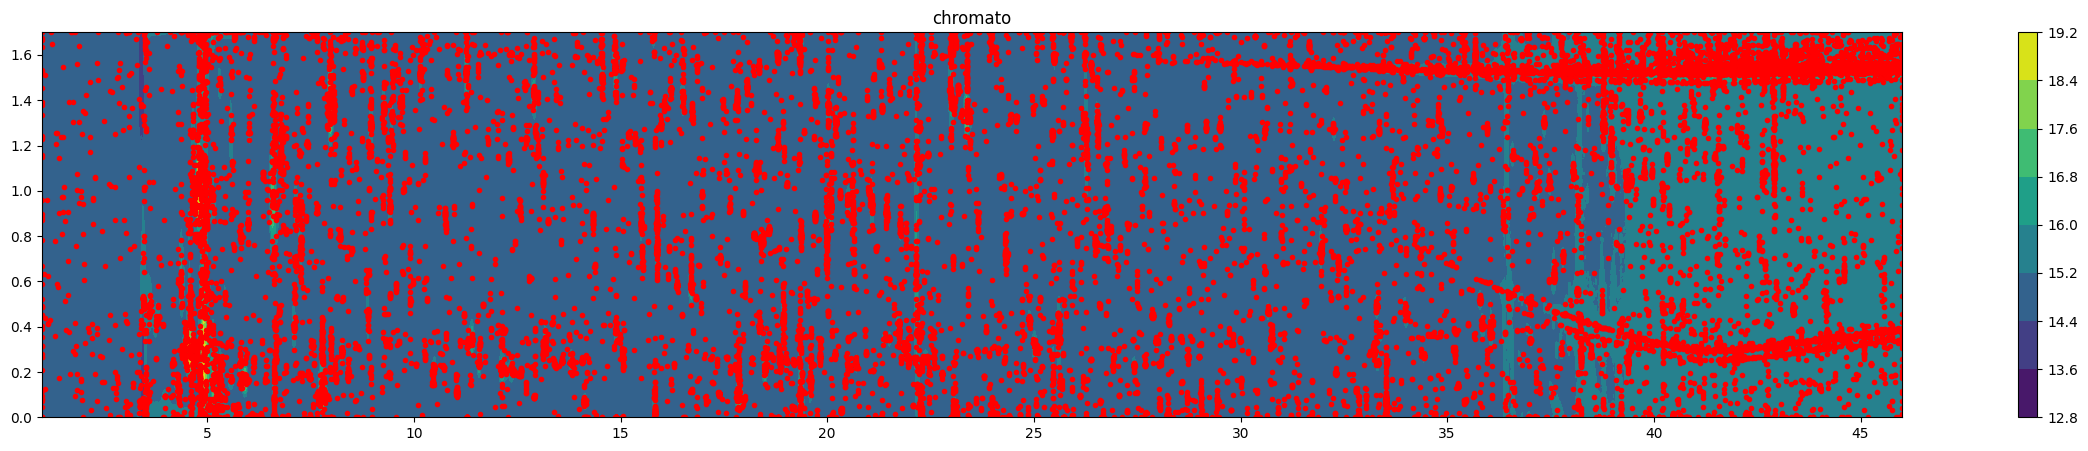

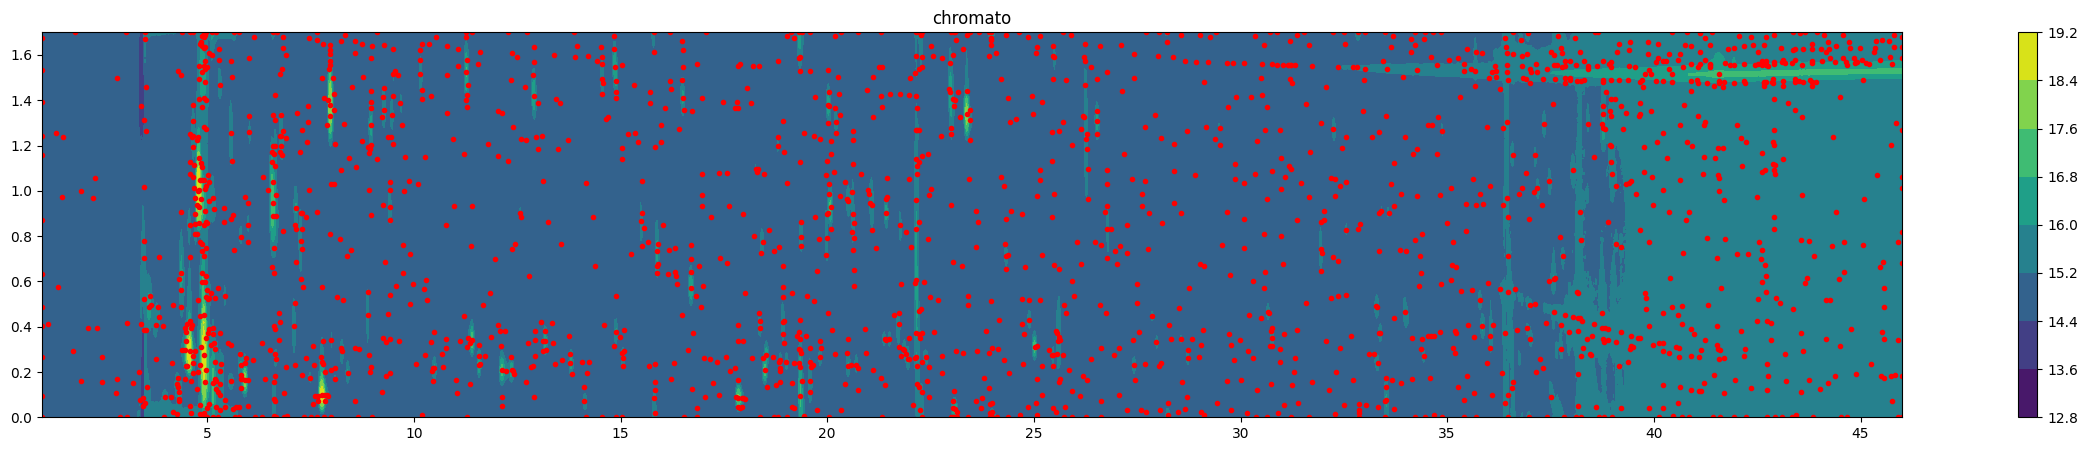

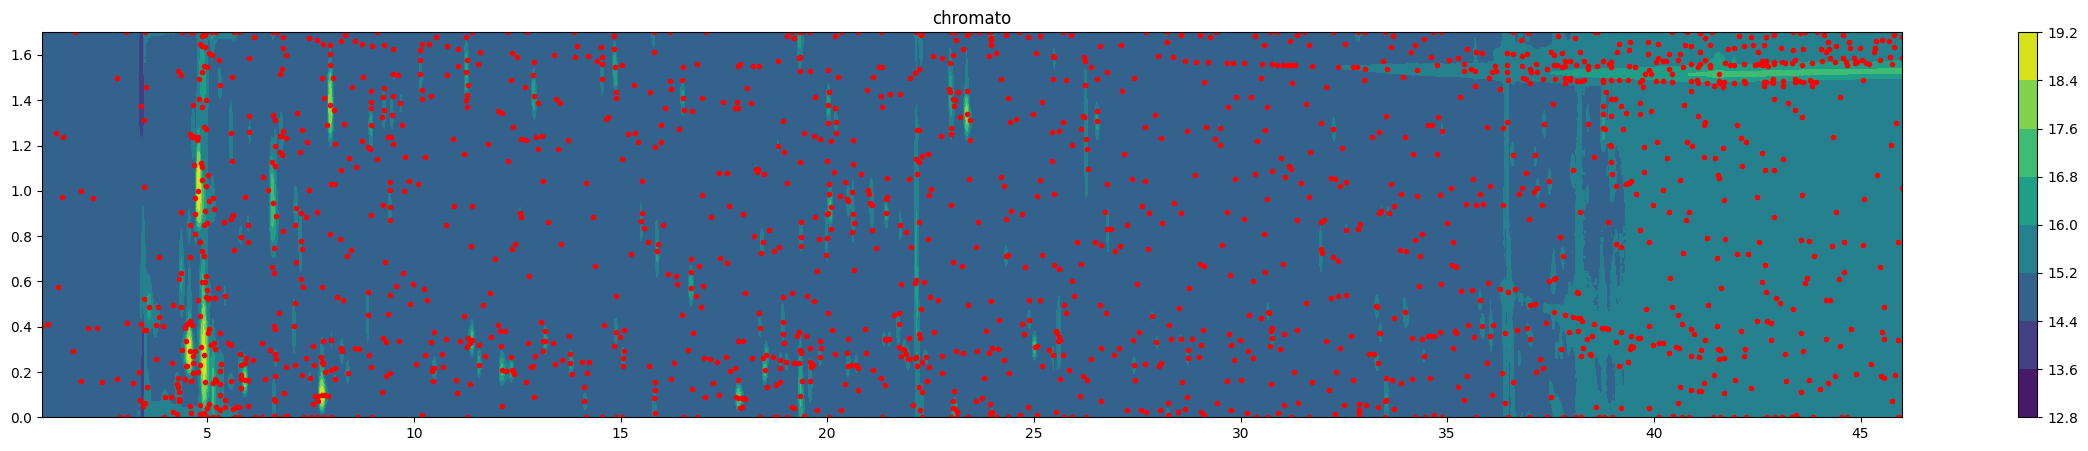

In [136]:
plt.rcParams['figure.figsize'] = [30, 5]
coordinates_in_chromato=projection.matrix_to_chromato(coordinates_all_mass, time_rn, 1.7, chromato.shape)
visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)
coordinates_in_chromato=projection.matrix_to_chromato(coordinates_final, time_rn, 1.7, chromato.shape)
visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)

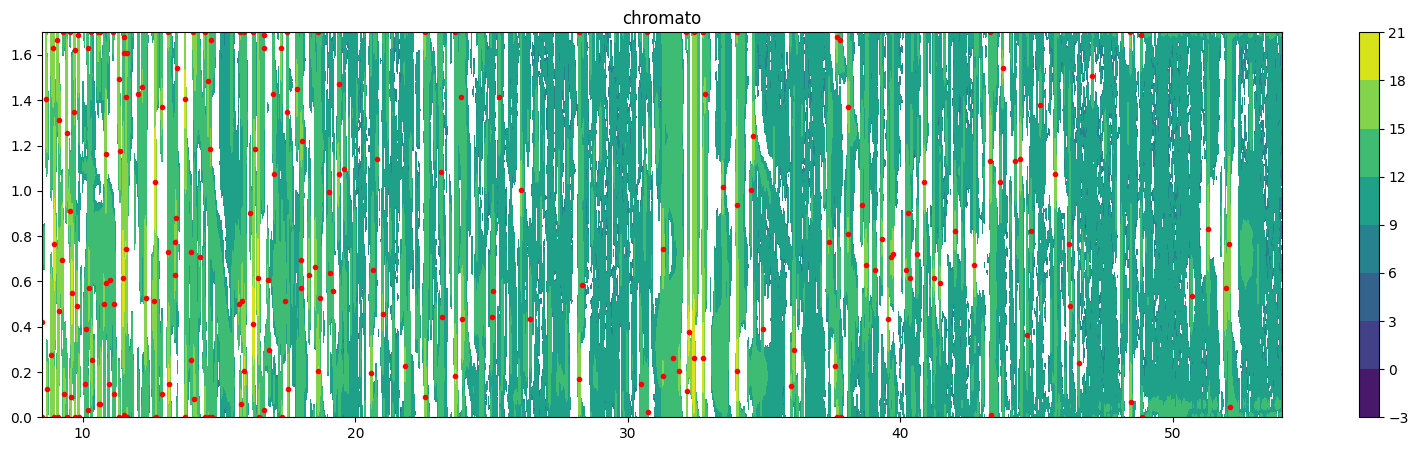

In [56]:
seuil=1
MIN_SEUIL = seuil * sigma * 100 / np.max(chromato)
# detect peaks
#coordinates = peak_detection((chromato, time_rn, None), None, chromato_cube, MIN_SEUIL, None , mode='tic' )
coordinates_TIC = peak_detection((chromato, time_rn, mass_range), spectra=mass_range, mod_time=1.7,method = "persistent_homology",chromato_cube=chromato_cube,    
                             seuil=0.005,ABS_THRESHOLDS=None, mode='tic', cluster=True,  
                             min_distance=1, sigma_ratio=1.6, num_sigma=10, unique=False)
len(coordinates_TIC)
coordinates_in_chromato_TIC=projection.matrix_to_chromato(coordinates_TIC, time_rn, 1.7, chromato.shape)
plot.visualizer((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato_TIC)

In [ ]:
coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1) # supp l'info de la mass



clustering = DBSCAN(eps=0.5, min_samples=5).fit(coordinates_all_mass) # lance DBscan
clusters = []
for i in range((np.max(clustering.labels_) + 1)):
    clusters.append([])

for i, (t1, t2) in enumerate(coordinates_all_mass):
    clusters[clustering.labels_[i]].append([t1, t2])

# clusters = np.array(clusters)
# Coordinates of the point with the biggest intensity in the cluster for every clusters
coordinates = []
for cluster in clusters:
    if (len(cluster) > 1):
        #coord = cluster[np.argmax(np.array([chromato[coord[0], coord[1]] for coord in cluster]))]
        arr=np.array(cluster)
        median_x = np.median(arr[:, 0])  # Median of first coordinate
        median_y = np.median(arr[:, 1])  # Median of second coordinate
        coord=[round(median_x),round(median_y)]
    else:
        coord = cluster[0]
    coordinates.append(coord)
coordinates = np.array(coordinates)

# anotate table

In [20]:
import pandas as pd
import logging
import pyms
import pyms_nist_search



def serialize_hit_tuple(hit_tuple):
        search_result, ref_data = hit_tuple
        return {
            "name": getattr(search_result, "name", None),
            "match_factor": getattr(search_result, "match_factor", None),
            "cas_number": getattr(search_result, "cas", None),
            "formula": getattr(ref_data, "formula", None),
        }

def filter_best_hits(list_hits, match_factor_min):
    match_factors = [hit["match_factor"] for hit in list_hits]
    max_match_factor = max(match_factors, default=0)

    filtered_hits = [
        hit for hit in list_hits
        if hit["match_factor"] >= max_match_factor - 100
        and hit["match_factor"] >= match_factor_min
    ]
    return filtered_hits

def matching_nist(df,match_factor_min):  
    search = pyms_nist_search.Engine(
        "C:/Users/camil/Documents/NIST/mainlib/",
        pyms_nist_search.NISTMS_MAIN_LIB,
        "C:/Users/camil/Documents/NIST/mainlib/",
        )

    logger=logging.getLogger('pyms_nist_search')
    logger.setLevel('ERROR')
    logger=logging.getLogger('pyms')
    logger.setLevel('ERROR')

    df['compound_name'] = ""
    df['casno'] = ""
    df['compound_formula'] = ""
    df['match_factor'] = ""

    for row in range(df.shape[0]):
        s = df.at[row, 'Spectra']
        pairs = s.strip().split()

        masses = []
        intensities = []

        for pair in pairs:
                m, i = pair.split(":")
                masses.append(int(float(m)))  #  or float(m) if decimals matter
                intensities.append(float(i))
        
        list_hits = []
        mass_spectrum = pyms.Spectrum.MassSpectrum(masses, intensities)

        hits = search.full_search_with_ref_data(mass_spectrum, n_hits=20)
        for i, hit_tuple in enumerate(hits):
            results = serialize_hit_tuple(hit_tuple)
            list_hits.append(results)
        top_hits = filter_best_hits(list_hits, match_factor_min)

        def join_field(field):
            return '/'.join(str(m.get(field, '')) for m in top_hits)

        if top_hits:
            identification_data_dict = {
            'compound_name': join_field('name'),
            'casno': join_field('cas_number'),
            'compound_formula': join_field('formula'),
            'match_factor': join_field('match_factor'),
        }
            for key in identification_data_dict:
                df.at[row, key] = identification_data_dict[key]

    return df

In [15]:
search = pyms_nist_search.Engine(
        "C:/Users/camil/Documents/NIST/mainlib/",
        pyms_nist_search.NISTMS_MAIN_LIB,
        "C:/Users/camil/Documents/NIST/mainlib/",
        )

logger=logging.getLogger('pyms_nist_search')
logger.setLevel('ERROR')
logger=logging.getLogger('pyms')
logger.setLevel('ERROR')
df = pd.read_csv("C:/Users/camil/data/VOC-Compare/gcgc/resultat mass_par_mass_dog/output_python2dgc_reciva/align_table_Reciva_info_without_outlier.csv", sep=";")

df['compound_name'] = ""
df['casno'] = ""
df['compound_formula'] = ""
df['match_factor'] = ""


In [17]:
top_hits

[]

In [19]:
row=10

s = df.at[row, 'Spectra']
pairs = s.strip().split()

masses = []
intensities = []

for pair in pairs:
    m, i = pair.split(":")
    masses.append(int(float(m))) 
    intensities.append(float(i))
        
list_hits = []
mass_spectrum = pyms.Spectrum.MassSpectrum(masses, intensities)

hits = search.full_search_with_ref_data(mass_spectrum, n_hits=20)
for i, hit_tuple in enumerate(hits):
    results = serialize_hit_tuple(hit_tuple)
    list_hits.append(results)
top_hits = filter_best_hits(list_hits, match_factor_min)

def join_field(field):
    return '/'.join(str(m.get(field, '')) for m in top_hits)

if top_hits:
    identification_data_dict = {
            'compound_name': join_field('name'),
            'casno': join_field('cas_number'),
            'compound_formula': join_field('formula'),
            'match_factor': join_field('match_factor'),
        }
    for key in identification_data_dict:
        df.at[row, key] = identification_data_dict[key]



In [21]:
match_factor_min = 700
df = pd.read_csv("C:/Users/camil/data/VOC-Compare/gcgc/resultat mass_par_mass_dog/output_python2dgc_reciva/align_table_Reciva_info_without_outlier.csv", sep=";")
   
df = matching_nist(df,match_factor_min)
    
#df.to_csv("Annotate/align_table_info_annotated_hits.csv", sep=";", index=False, encoding="utf-8-sig") #compatibilite avec excel

c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\pyms\Spectrum.py:98: UserWarning: Unknown sort order for mass list; it doesn't appear to be in either ascending or descending order.
Please report this at https://github.com/domdfcoding/pymassspec/issues and upload an example data file if possible.

  warnings.warn(
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\pyms_nist_search\utils.py:123: UserWarning: Unable to parse the following character codes for string �,�-Oxidoethane: [-32, -31].
  warnings.warn(f"Unable to parse the following character codes for string {hit_name}: {errors}.")
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\pyms_nist_search\utils.py:123: UserWarning: Unable to parse the following character codes for string D-�-Alanine: [-32].
  warnings.warn(f"Unable to parse the following character codes for string {hit_name}: {errors}.")
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-p

In [22]:
df

,Name,R.T...s.,Area,Quant.Masses,Spectra,RT1,RT2,compound_name,casno,compound_formula,match_factor
0,Analyte137_1,"""214.82026554010315 , 0.4964601769911504""","247752277,9",True,44.0:4379309.0608854415 43.0:2394450.142891567...,"214,8202655","0,496460177",Acetaldehyde/Azodicarbonamide/Semicarbazide,75-7-0/---/4426-72-6,C2H4O/C2H4N4O2/CH5N3O,898/840/822
1,Analyte142_1,"""262.45726812088645 , 0.6519174041297935""","811958562,3",True,45.0:10870953.086944519 46.0:4429660.112933215...,"262,4572681","0,651917404",Ethanol,64-17-5,C2H6O,920
2,Analyte6_1,"""272.6651972453401 , 0.2958702064896755""",1917305762,True,67.0:26434317.979477495 68.0:19189942.94061720...,"272,6651972","0,295870206","Cyclopropane, ethylidene-/1,4-Pentadiene/1,3-P...",18631-83-9/591-93-5/2004-70-8/1574-41-0/14309-...,C5H8/C5H8/C5H8/C5H8/C5H8/C5H8/C5H8/C5H8N2/C5H8...,952/943/938/934/931/928/925/909/908/905/900/89...
3,Analyte8_1,"""287.9770909320204 , 1.0129793510324483""",7119269719,True,43.0:88745069.71263774 58.0:32572461.80009525 ...,"287,9770909","1,012979351","Acetone/Oxirane, methyl-, (S)-/Diisobutyl cell...",67-64-1/16088-62-3/---,C3H6O/C3H6O/C10H22O2,902/854/812
4,Analyte9_1,"""294.78237701498944 , 0.3209439528023599""",23068841634,True,45.0:66769017.439926095 43.0:20388893.78208378...,"294,782377","0,320943953",Isopropyl Alcohol,67-63-0,C3H8O,928
...,...,...,...,...,...,...,...,...,...,...,...
150,Analyte1155_1,"""2365.2906677583214 , 1.073156342182891""","12273218,04",True,91.0:275433.82743925625 105.0:105817.153735814...,"2365,290668","1,073156342","Benzene, (1-butyloctyl)-",2719-63-3,C18H30,734
151,Analyte199_1,"""2378.9012399242597 , 1.37905604719764""","2021804,507",True,57.0:90040.69347310392 43.0:87058.65710548553 ...,"2378,90124","1,379056047",Tridecanal/13-Methyltetradecanal/Pentadecanal-...,10486-19-8/75853-51-9/2765-11-9/74962-98-4/638...,C13H26O/C15H30O/C15H30O/C13H26O/C18H36O/C18H34...,766/760/757/751/749/737/734/731/730/729/727/72...
152,Analyte153_1,"""2424.836920984301 , 0.5064896755162241""","11661965,6",True,57.0:507002.4012702396 43.0:354405.7104499246 ...,"2424,836921","0,506489676",Hexadecane/Heptadecane/Octadecane/Pentadecane/...,544-76-3/629-78-7/593-45-3/629-62-9/629-92-5/5...,C16H34/C17H36/C18H38/C15H32/C19H40/C21H44/C20H...,824/816/810/800/798/792/788/787/782/782/780/77...
153,Analyte593_1,"""2472.473923565084 , 1.3339233038348082""","15706083,24",True,105.0:565020.1743151195 106.0:81466.6429280138...,"2472,473924","1,333923304","Benzene, (1-methylundecyl)-",2719-61-1,C18H30,700


In [23]:
df.to_csv("C:/Users/camil/data/VOC-Compare/gcgc/resultat mass_par_mass_dog/output_python2dgc_reciva/align_table_Reciva_info_annotate_without_outlier.csv", sep=";", index=False, encoding="utf-8-sig") #compatibilite avec excel